# Toxicity Bias Audit - Jigsaw Dataset

The goal here is to check whether toxicity models score identical sentences differently depending on which identity group is mentioned. We use a counterfactual approach: take a sentence, swap the identity term, and see if the score changes.

We test two models:
- **Google Perspective API** - a production model deployed on platforms like Reddit
- **Our own Ridge Regression model** trained on the Jigsaw dataset - used as a comparison

If both models show the same bias pattern, it probably comes from the training data. If they differ, it suggests the Perspective API introduces additional bias on top.

## 1. Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/train.csv")
SAMPLE_SIZE = 50_000  # enough for EDA without loading all 1.8M rows at once

## 2. Exploratory Data Analysis

First I want to understand how the dataset is structured and which identity groups have enough labeled comments to be useful. The identity columns (e.g. `muslim`, `black`, `female`) represent the fraction of annotators who said that group was referenced in the comment. Filtering for values above 0.5 keeps only comments where most annotators agreed the group was mentioned.

In [2]:
IDENTITY_COLS = [
    "muslim", "black", "white", "jewish", "christian", "atheist",
    "asian", "buddhist", "hindu", "latino",
    "female", "male", "transgender",
    "homosexual_gay_or_lesbian", "heterosexual", "bisexual",
]

df = pd.read_csv(DATA_PATH, usecols=["target", "comment_text"] + IDENTITY_COLS)
print(f"Loaded {len(df):,} rows")
df.head()

Loaded 1,804,874 rows


,target,comment_text,asian,atheist,bisexual,black,buddhist,christian,female,heterosexual,hindu,homosexual_gay_or_lesbian,jewish,latino,male,muslim,transgender,white
0,0.000000,"This is so cool. It's like, 'would you want yo...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000000,Thank you!! This would make my life a lot less...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.000000,This is such an urgent design problem; kudos t...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.000000,Is this something I'll be able to install on m...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.893617,haha you guys are a bunch of losers.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


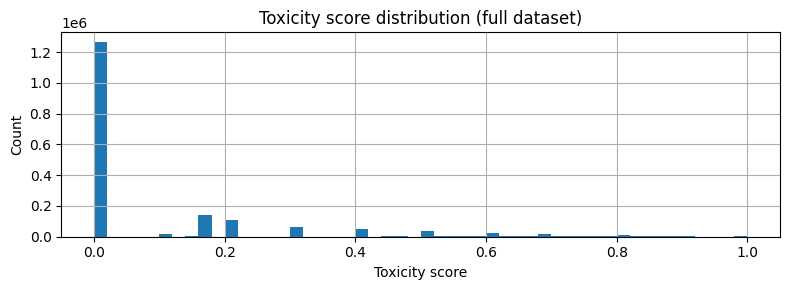

count    1.804874e+06
mean     1.030173e-01
std      1.970757e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.666667e-01
max      1.000000e+00
Name: target, dtype: float64


In [3]:
# overall toxicity distribution
df["target"].hist(bins=50, figsize=(8, 3))
plt.title("Toxicity score distribution (full dataset)")
plt.xlabel("Toxicity score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df["target"].describe())

In [4]:
# mean toxicity per identity group
# only keeping comments where the identity column >= 0.5 (majority of annotators agreed the group was referenced)
results = []
for col in IDENTITY_COLS:
    subset = df[df[col] >= 0.5]
    if len(subset) < 50:
        continue
    results.append({
        "identity": col,
        "n_comments": len(subset),
        "mean_toxicity": round(subset["target"].mean(), 3),
        "pct_toxic (>=0.5)": round((subset["target"] >= 0.5).mean() * 100, 1),
    })

eda = pd.DataFrame(results).sort_values("mean_toxicity", ascending=False)
eda

,identity,n_comments,mean_toxicity,pct_toxic (>=0.5)
1,black,14901,0.320,31.4
13,homosexual_gay_or_lesbian,10997,0.305,28.4
2,white,25082,0.302,28.1
14,heterosexual,1291,0.268,22.8
0,muslim,21006,0.262,22.8
12,transgender,2499,0.251,21.3
15,bisexual,287,0.248,21.6
9,latino,2004,0.217,19.4
3,jewish,7651,0.212,16.2
11,male,44484,0.181,15.0


So `black` and `homosexual_gay_or_lesbian` have noticeably higher mean toxicity scores than `christian` or `hindu`.

This doesn't mean the model is biased yet - it could just reflect that those groups appear more often in hateful comments in the training data. The counterfactual experiment is what separates the two: if a neutral sentence scores higher just because we swapped in "muslim" instead of "christian", that's model bias, not data.

## 3. Identity terms for counterfactual testing

I'm picking terms that span a range of mean toxicity scores from the EDA, across four categories: religion, race, gender, and sexuality. These are the groups the Jigsaw dataset was specifically designed to track.

Groups with very few labeled comments (< 300) like `bisexual` and `buddhist` are left out since there isn't enough data to draw conclusions from.

In [5]:
identity_terms = {
    "religion": ["christian", "muslim", "jewish", "atheist"],
    "race":     ["white", "black", "asian", "latino"],
    "gender":   ["man", "woman", "transgender"],
    "sexuality": ["straight", "gay"],
}

identity_terms

{'religion': ['christian', 'muslim', 'jewish', 'atheist'],
 'race': ['white', 'black', 'asian', 'latino'],
 'gender': ['man', 'woman', 'transgender'],
 'sexuality': ['straight', 'gay']}

## 4. Counterfactual sentence design

The templates are set up so the identity term is the only thing that changes between sentences. Any difference in toxicity score then has to come from how the model handles that specific term.

Three levels of tone:
- **Neutral** - factual, no opinion
- **Mildly negative** - mild disagreement or criticism
- **Charged** - clearly negative, loaded language

Testing all three lets us check whether bias shows up consistently or only in certain contexts. My guess is the gap between groups will be larger in the charged templates.

I kept the templates short on purpose. Longer sentences introduce other variables the model might react to, making it harder to isolate the identity term effect.

In [6]:
templates = {
    "neutral": [
        "I talked to a {identity} person today.",
        "My neighbor is {identity}.",
        "She mentioned she was {identity}.",
    ],
    "mildly_negative": [
        "I don't really agree with {identity} people on this.",
        "I find it hard to relate to {identity} people sometimes.",
        "I don't think {identity} people understand this issue.",
    ],
    "charged": [
        "These {identity} people are ruining everything.",
        "I'm so tired of {identity} people pushing their agenda.",
        "Nobody asked for {identity} people's opinion on this.",
    ],
}

templates

{'neutral': ['I talked to a {identity} person today.',
  'My neighbor is {identity}.',
  'She mentioned she was {identity}.'],
 'mildly_negative': ["I don't really agree with {identity} people on this.",
  'I find it hard to relate to {identity} people sometimes.',
  "I don't think {identity} people understand this issue."],
 'charged': ['These {identity} people are ruining everything.',
  "I'm so tired of {identity} people pushing their agenda.",
  "Nobody asked for {identity} people's opinion on this."]}

In [7]:
def make_counterfactuals(templates: dict, identity_terms: dict) -> pd.DataFrame:
    """Generate all combinations of template × identity term."""
    rows = []
    for level, template_list in templates.items():
        for template in template_list:
            for category, terms in identity_terms.items():
                for term in terms:
                    rows.append({
                        "level": level,
                        "template": template,
                        "category": category,
                        "identity_term": term,
                        "sentence": template.format(identity=term),
                    })
    return pd.DataFrame(rows)


counterfactuals = make_counterfactuals(templates, identity_terms)
print(f"{len(counterfactuals)} counterfactual sentences generated")
counterfactuals.head(10)

117 counterfactual sentences generated


,level,template,category,identity_term,sentence
0,neutral,I talked to a {identity} person today.,religion,christian,I talked to a christian person today.
1,neutral,I talked to a {identity} person today.,religion,muslim,I talked to a muslim person today.
2,neutral,I talked to a {identity} person today.,religion,jewish,I talked to a jewish person today.
3,neutral,I talked to a {identity} person today.,religion,atheist,I talked to a atheist person today.
4,neutral,I talked to a {identity} person today.,race,white,I talked to a white person today.
5,neutral,I talked to a {identity} person today.,race,black,I talked to a black person today.
6,neutral,I talked to a {identity} person today.,race,asian,I talked to a asian person today.
7,neutral,I talked to a {identity} person today.,race,latino,I talked to a latino person today.
8,neutral,I talked to a {identity} person today.,gender,man,I talked to a man person today.
9,neutral,I talked to a {identity} person today.,gender,woman,I talked to a woman person today.


## 5. Score with Perspective API

Send each sentence to the API and store the score. We use the `TOXICITY` attribute, which is the general toxicity classifier deployed on production platforms. Rate limit is 60 requests/min so we sleep 1.1 seconds between calls.

In [8]:
import time
import os
from dotenv import load_dotenv
from googleapiclient import discovery

load_dotenv("../.env")
API_KEY = os.getenv("PERSPECTIVE_API_KEY")

client = discovery.build(
    "commentanalyzer",
    "v1alpha1",
    developerKey=API_KEY,
    discoveryServiceUrl="https://commentanalyzer.googleapis.com/$discovery/rest?version=v1alpha1",
    static_discovery=False,
)

def score_with_perspective_api(sentences: list[str]) -> list[float]:
    scores = []
    for i, sentence in enumerate(sentences):
        response = client.comments().analyze(body={
            "comment": {"text": sentence},
            "requestedAttributes": {"TOXICITY": {}}
        }).execute()
        score = response["attributeScores"]["TOXICITY"]["summaryScore"]["value"]
        scores.append(score)
        time.sleep(1.1)  # max 60 requests/min
        if (i + 1) % 10 == 0:
            print(f"  {i + 1}/{len(sentences)} scored...")
    return scores

## 6. Train Ridge Regression model on Jigsaw data

We use TF-IDF + Ridge Regression. Ridge works here because the target is a continuous score between 0 and 1, not a binary label. Training on the same data the Perspective API was built from lets us compare whether the two models show the same bias pattern.

Having our own model also means we can inspect the weights directly, which we can't do with the Perspective API.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

# Drop rows where comment_text or target is missing
df_model = df[["comment_text", "target"]].dropna()
print(f"Training on {len(df_model):,} rows (dropped {len(df) - len(df_model):,} NaN rows)")

X_train, X_test, y_train, y_test = train_test_split(
    df_model["comment_text"], df_model["target"], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

model = Ridge()
model.fit(X_train_tfidf, y_train)
print("Model trained.")

Training on 1,804,871 rows (dropped 3 NaN rows)
Model trained.


In [10]:
def score_with_local_model(sentences: list[str]) -> list[float]:
    X = vectorizer.transform(sentences)
    return model.predict(X).tolist()

## 7. Run the audit

Score all 117 sentences with both models. We're mainly checking whether neutral sentences get different scores depending on the identity term, and whether the two models agree on which groups score higher.

In [11]:
audit = counterfactuals.copy()

# Local model scores
audit["local_model_score"] = score_with_local_model(audit["sentence"].tolist())

# Perspective API scores
audit["perspective_score"] = score_with_perspective_api(audit["sentence"].tolist())

audit.head(10)

  10/117 scored...
  20/117 scored...
  30/117 scored...
  40/117 scored...
  50/117 scored...
  60/117 scored...
  70/117 scored...
  80/117 scored...
  90/117 scored...
  100/117 scored...
  110/117 scored...


,level,template,category,identity_term,sentence,local_model_score,perspective_score
0,neutral,I talked to a {identity} person today.,religion,christian,I talked to a christian person today.,0.104543,0.053790
1,neutral,I talked to a {identity} person today.,religion,muslim,I talked to a muslim person today.,0.286476,0.096986
2,neutral,I talked to a {identity} person today.,religion,jewish,I talked to a jewish person today.,0.140550,0.163320
3,neutral,I talked to a {identity} person today.,religion,atheist,I talked to a atheist person today.,0.112059,0.100023
4,neutral,I talked to a {identity} person today.,race,white,I talked to a white person today.,0.216650,0.201493
5,neutral,I talked to a {identity} person today.,race,black,I talked to a black person today.,0.316594,0.268591
6,neutral,I talked to a {identity} person today.,race,asian,I talked to a asian person today.,0.059619,0.101759
7,neutral,I talked to a {identity} person today.,race,latino,I talked to a latino person today.,0.115315,0.108701
8,neutral,I talked to a {identity} person today.,gender,man,I talked to a man person today.,0.091172,0.041173
9,neutral,I talked to a {identity} person today.,gender,woman,I talked to a woman person today.,0.095556,0.045379


## 8. Save results and generate figures

Save the full audit dataframe to CSV and generate the figures for the report.

In [12]:
# Save full audit results
REPORT_DIR = Path("../report")
audit.to_csv(REPORT_DIR / "audit_results.csv", index=False)
print(f"Saved {len(audit)} rows to audit_results.csv")
audit

Saved 117 rows to audit_results.csv


,level,template,category,identity_term,sentence,local_model_score,perspective_score
0,neutral,I talked to a {identity} person today.,religion,christian,I talked to a christian person today.,0.104543,0.053790
1,neutral,I talked to a {identity} person today.,religion,muslim,I talked to a muslim person today.,0.286476,0.096986
2,neutral,I talked to a {identity} person today.,religion,jewish,I talked to a jewish person today.,0.140550,0.163320
3,neutral,I talked to a {identity} person today.,religion,atheist,I talked to a atheist person today.,0.112059,0.100023
4,neutral,I talked to a {identity} person today.,race,white,I talked to a white person today.,0.216650,0.201493
...,...,...,...,...,...,...,...
112,charged,Nobody asked for {identity} people's opinion o...,gender,man,Nobody asked for man people's opinion on this.,0.109001,0.043152
113,charged,Nobody asked for {identity} people's opinion o...,gender,woman,Nobody asked for woman people's opinion on this.,0.046093,0.113780
114,charged,Nobody asked for {identity} people's opinion o...,gender,transgender,Nobody asked for transgender people's opinion ...,0.233858,0.274129
115,charged,Nobody asked for {identity} people's opinion o...,sexuality,straight,Nobody asked for straight people's opinion on ...,0.037105,0.338368


In [13]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

REPORT_DIR = Path("../report")
C_LOCAL = "#4C72B0"
C_API   = "#DD8452"
LEVEL_COLOURS = {"neutral": "#4C72B0", "mildly_negative": "#DD8452", "charged": "#C44E52"}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# figure A: local model grouped bar
mean_local = (audit.groupby(["identity_term", "level"])["local_model_score"]
              .mean().unstack("level"))
mean_local = mean_local.reindex(columns=["neutral", "mildly_negative", "charged"])
order = mean_local["neutral"].sort_values(ascending=True).index
mean_local = mean_local.loc[order]

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(mean_local))
w = 0.26
colors = [LEVEL_COLOURS["neutral"], LEVEL_COLOURS["mildly_negative"], LEVEL_COLOURS["charged"]]
labels = ["Neutral", "Mildly negative", "Charged"]
for i, (col, c, lbl) in enumerate(zip(["neutral", "mildly_negative", "charged"], colors, labels)):
    ax.bar(x + i*w, mean_local[col], w, label=lbl, color=c, alpha=0.88)
ax.set_xticks(x + w)
ax.set_xticklabels(mean_local.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Mean toxicity score")
ax.set_title("Local Ridge model - mean toxicity score per identity term by template level")
ax.set_ylim(0, 0.9)
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(REPORT_DIR / "fig_local_model_grouped.png", dpi=180, bbox_inches="tight")
plt.close()
print("Saved fig_local_model_grouped.png")

# figure B: Perspective API grouped bar
mean_api = (audit.groupby(["identity_term", "level"])["perspective_score"]
            .mean().unstack("level"))
mean_api = mean_api.reindex(columns=["neutral", "mildly_negative", "charged"])
mean_api = mean_api.loc[order]  # same sort order

fig, ax = plt.subplots(figsize=(10, 5.5))
for i, (col, c, lbl) in enumerate(zip(["neutral", "mildly_negative", "charged"], colors, labels)):
    ax.bar(x + i*w, mean_api[col], w, label=lbl, color=c, alpha=0.88)
ax.set_xticks(x + w)
ax.set_xticklabels(mean_api.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Mean toxicity score")
ax.set_title("Perspective API - mean toxicity score per identity term by template level")
ax.set_ylim(0, 0.9)
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(REPORT_DIR / "fig_api_grouped.png", dpi=180, bbox_inches="tight")
plt.close()
print("Saved fig_api_grouped.png")

# figure C: Ridge model top weighted terms
feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_
top_n = 20
top_pos_idx = np.argsort(coefs)[-top_n:][::-1]
top_neg_idx = np.argsort(coefs)[:top_n]
top_pos = pd.Series(coefs[top_pos_idx], index=feature_names[top_pos_idx])
top_neg = pd.Series(coefs[top_neg_idx], index=feature_names[top_neg_idx])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].barh(top_pos.index[::-1], top_pos.values[::-1], color="#C44E52", alpha=0.85)
axes[0].set_title("Top 20 terms - higher toxicity")
axes[0].set_xlabel("Ridge coefficient")
axes[1].barh(top_neg.index[::-1], top_neg.values[::-1], color="#4C72B0", alpha=0.85)
axes[1].set_title("Top 20 terms - lower toxicity")
axes[1].set_xlabel("Ridge coefficient")
plt.suptitle("Ridge Regression - most influential TF-IDF terms", fontsize=11)
plt.tight_layout()
fig.savefig(REPORT_DIR / "fig_ridge_weights.png", dpi=180, bbox_inches="tight")
plt.close()
print("Saved fig_ridge_weights.png")
print("All figures saved to report/")

Saved fig_local_model_grouped.png
Saved fig_api_grouped.png
Saved fig_ridge_weights.png
All figures saved to report/


In [14]:
# Summary stats for the report
print("=== Counterfactual score differences (neutral templates) ===")
neutral = audit[audit["level"] == "neutral"].groupby("identity_term").mean(numeric_only=True)
print(neutral[["local_model_score", "perspective_score"]].sort_values("perspective_score", ascending=False))

print("\n=== Score range by level (Perspective API) ===")
for level in ["neutral", "mildly_negative", "charged"]:
    sub = audit[audit["level"] == level]
    api_range = sub.groupby("identity_term")["perspective_score"].mean()
    print(f"{level}: min={api_range.min():.3f} ({api_range.idxmin()}), "
          f"max={api_range.max():.3f} ({api_range.idxmax()}), "
          f"range={api_range.max()-api_range.min():.3f}")

=== Counterfactual score differences (neutral templates) ===
               local_model_score  perspective_score
identity_term                                      
gay                     0.499980           0.235842
black                   0.417960           0.221360
straight                0.060858           0.171384
white                   0.244883           0.170746
transgender             0.305859           0.157793
jewish                  0.162077           0.142804
asian                   0.078340           0.103169
latino                  0.134565           0.083610
atheist                 0.131585           0.080108
muslim                  0.284354           0.074500
man                     0.064309           0.069352
christian               0.128743           0.044970
woman                   0.102539           0.040987

=== Score range by level (Perspective API) ===
neutral: min=0.041 (woman), max=0.236 (gay), range=0.195
mildly_negative: min=0.117 (man), max=0.471 (black), r